# Assignment 2: From Trees to Neural Networks
**Dataset:** Home Credit Default Risk (`application_train.csv`)  
**Task:** Predict if a loan applicant will default (`TARGET` = 1) or repay (`TARGET` = 0)  
**Models:** XGBoost (GBDT) vs MLPClassifier  
**Main file used:** `home-credit-default-risk/application_train.csv`

## Section 0: Imports & Setup

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn — modeling & evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score, roc_auc_score,
    classification_report, precision_recall_curve
)

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

# Reproducibility — set this once at the top
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'XGBoost version: {xgb.__version__}')
print('All imports successful.')

XGBoost version: 3.2.0
All imports successful.


## Section 1: Data Loading

In [49]:
df = pd.read_csv('home-credit-default-risk/application_train.csv')

print(f"Shape: {df.shape}")
print(df['TARGET'].value_counts())
df.head()

Shape: (307511, 122)
TARGET
0    282686
1     24825
Name: count, dtype: int64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Section 2: Exploratory Data Analysis (EDA)

Shape: (307511, 122)

Data Types:
float64    65
int64      41
str        16
Name: count, dtype: int64

Target Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Balance: 8.1% defaults

67 columns have missing values
COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64


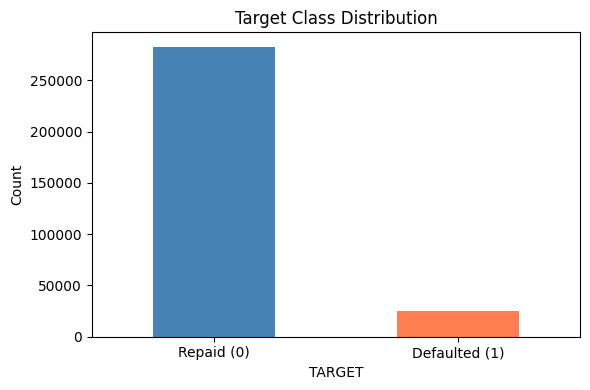

Saved: eda_target_distribution.png


In [50]:
# Data overview
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nTarget Distribution:\n{df['TARGET'].value_counts()}")
print(f"\nTarget Balance: {df['TARGET'].mean()*100:.1f}% defaults")

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"\n{len(missing)} columns have missing values")
print(missing.head(20))

# Plot target distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['TARGET'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Target Class Distribution')
ax.set_xticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150)
plt.show()
print("Saved: eda_target_distribution.png")

## Section 3: Data Preparation
No data leakage — split FIRST, then fit transformers on train only.

In [51]:
# 3.1 Drop high-missing columns + separate X and y

# Drop columns missing more than 60% of values
thresh = 0.6
missing_frac = df.isnull().mean()
cols_to_drop = missing_frac[missing_frac > thresh].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >60% missing: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# Separate features and target
# SK_ID_CURR is just a loan ID — no predictive value, must be removed
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Positive class rate: {y.mean()*100:.1f}%")

Dropping 17 columns with >60% missing: ['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']

X shape: (307511, 103)
y shape: (307511,)
Positive class rate: 8.1%


In [52]:
# 3.2 Train / Validation / Test Split (70 / 15 / 15)
# SPLIT BEFORE any imputation or encoding — fitting transformers on full data leaks test info

from sklearn.model_selection import train_test_split

# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)

# Step 2: split temp 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Train size:      {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation size: {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test size:       {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train positive rate: {y_train.mean()*100:.1f}%  (stratify kept it balanced)")

Train size:      215,257 (70.0%)
Validation size: 46,127 (15.0%)
Test size:       46,127 (15.0%)

Features: 103
Train positive rate: 8.1%  (stratify kept it balanced)


In [53]:
# 3.3 Imputation + One-Hot Encoding (fit on train only — no leakage)

from sklearn.impute import SimpleImputer

# --- Identify column types ---
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"Categorical columns: {len(cat_cols)}")
print(f"Numeric columns:     {len(num_cols)}")

# --- Impute numeric: fill missing with MEDIAN (robust to outliers) ---
# Fit on train only, then apply to all three splits
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols]   = num_imputer.transform(X_val[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])

# --- Impute categorical: fill missing with most frequent value ---
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols]   = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])

# --- One-hot encode categoricals ---
# get_dummies on train, then align val/test to have the same columns
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_val   = pd.get_dummies(X_val,   columns=cat_cols)
X_test  = pd.get_dummies(X_test,  columns=cat_cols)

# Align columns — val/test may be missing some dummy columns that train has
X_val   = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"\nAfter encoding:")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nAny missing values left? {X_train.isnull().sum().sum()}")

Categorical columns: 15
Numeric columns:     88

After encoding:
X_train shape: (215257, 224)
X_val shape:   (46127, 224)
X_test shape:  (46127, 224)

Any missing values left? 0


In [54]:
# 3.4 Feature Scaling for MLP (fit on train only)
# WHY: MLP uses gradient descent. Features on different scales cause unstable training.
#      A column ranging 0-1 and a column ranging 0-1,000,000 will dominate gradients.
# WHY NOT for XGBoost: Trees split on rank/thresholds, not distances. Scale is irrelevant.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_val_scaled   = scaler.transform(X_val)          # transform only — use train's mean/std
X_test_scaled  = scaler.transform(X_test)         # transform only — use train's mean/std

print("Scaling complete.")
print(f"Train mean (should be ~0): {X_train_scaled.mean(axis=0)[:3].round(4)}")
print(f"Train std  (should be ~1): {X_train_scaled.std(axis=0)[:3].round(4)}")

Scaling complete.
Train mean (should be ~0): [0. 0. 0.]
Train std  (should be ~1): [1. 1. 1.]


## Section 4: Gradient Boosted Decision Trees (XGBoost)

In [55]:
# 4.1 Baseline XGBoost model with eval_set + early stopping

import time

# Class imbalance fix: 91.9% repaid vs 8.1% default (11x)
# scale_pos_weight tells XGBoost to weight minority class errors 11x more
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_baseline = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=RANDOM_SEED
)

start = time.time()
xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)
xgb_train_time = time.time() - start

print(f"\nBest iteration: {xgb_baseline.best_iteration}")
print(f"Training time:  {xgb_train_time:.2f}s")

scale_pos_weight: 11.39
[0]	validation_0-logloss:0.67850	validation_1-logloss:0.67868
[50]	validation_0-logloss:0.56306	validation_1-logloss:0.57230
[100]	validation_0-logloss:0.53979	validation_1-logloss:0.55545
[150]	validation_0-logloss:0.52353	validation_1-logloss:0.54434
[200]	validation_0-logloss:0.50750	validation_1-logloss:0.53359
[250]	validation_0-logloss:0.49280	validation_1-logloss:0.52394
[300]	validation_0-logloss:0.47889	validation_1-logloss:0.51484
[350]	validation_0-logloss:0.46626	validation_1-logloss:0.50697
[400]	validation_0-logloss:0.45438	validation_1-logloss:0.49924
[450]	validation_0-logloss:0.44109	validation_1-logloss:0.49065
[499]	validation_0-logloss:0.42933	validation_1-logloss:0.48329

Best iteration: 499
Training time:  10.58s


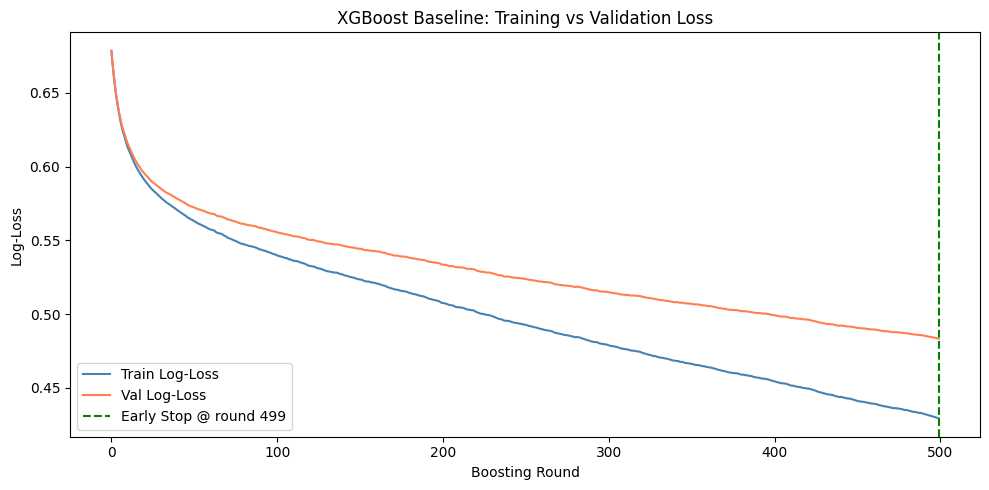

Saved: xgb_baseline_loss.png


In [56]:
# 4.2 Plot training vs validation loss

results = xgb_baseline.evals_result()
train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Log-Loss', color='steelblue')
plt.plot(val_loss,   label='Val Log-Loss',   color='coral')
plt.axvline(x=xgb_baseline.best_iteration, color='green', linestyle='--',
            label=f'Early Stop @ round {xgb_baseline.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('Log-Loss')
plt.title('XGBoost Baseline: Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_baseline_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xgb_baseline_loss.png")

lr=0.01: best_round=299, Val F1=0.2583
lr=0.1: best_round=299, Val F1=0.2739
lr=0.3: best_round=298, Val F1=0.2665


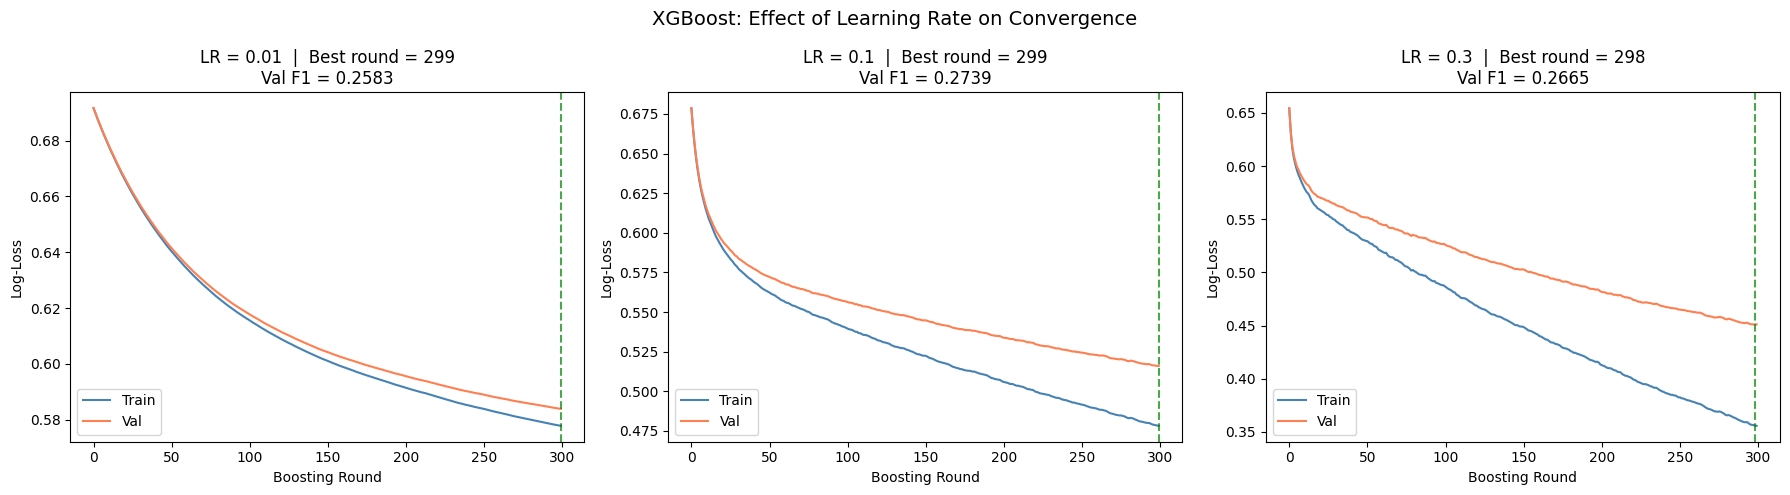

Saved: xgb_learning_rates.png


In [57]:
# 4.3 Effect of learning rate: compare 0.01, 0.1, 0.3

learning_rates = [0.01, 0.1, 0.3]
lr_val_f1 = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, lr in enumerate(learning_rates):
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=lr,
        max_depth=6,
        subsample=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        early_stopping_rounds=30,
        random_state=RANDOM_SEED
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )

    res = model.evals_result()
    val_pred = model.predict(X_val)
    val_f1 = f1_score(y_val, val_pred)
    lr_val_f1[lr] = val_f1

    axes[i].plot(res['validation_0']['logloss'], label='Train', color='steelblue')
    axes[i].plot(res['validation_1']['logloss'], label='Val',   color='coral')
    axes[i].axvline(x=model.best_iteration, color='green', linestyle='--', alpha=0.7)
    axes[i].set_title(f'LR = {lr}  |  Best round = {model.best_iteration}\nVal F1 = {val_f1:.4f}')
    axes[i].set_xlabel('Boosting Round')
    axes[i].set_ylabel('Log-Loss')
    axes[i].legend()

    print(f"lr={lr}: best_round={model.best_iteration}, Val F1={val_f1:.4f}")

plt.suptitle('XGBoost: Effect of Learning Rate on Convergence', fontsize=14)
plt.tight_layout()
plt.savefig('xgb_learning_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xgb_learning_rates.png")

In [58]:
# 4.4 Hyperparameter Tuning with RandomizedSearchCV
# Use a subsample of train for speed — still finds good params

from sklearn.model_selection import RandomizedSearchCV

# Use 30% of training data for the search to keep it fast
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=0.3,
    random_state=RANDOM_SEED, stratify=y_train
)
print(f"Tuning on {X_tune.shape[0]:,} samples")

param_dist = {
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1, 0.2],
    'n_estimators':     [100, 200],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'reg_alpha':        [0, 0.1, 1.0],
    'reg_lambda':       [1.0, 5.0],
}

xgb_cv = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_SEED
)

rscv = RandomizedSearchCV(
    xgb_cv,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

rscv.fit(X_tune, y_tune)

print(f"\nBest params: {rscv.best_params_}")
print(f"Best CV F1:  {rscv.best_score_:.4f}")

Tuning on 64,577 samples
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best params: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV F1:  0.2683


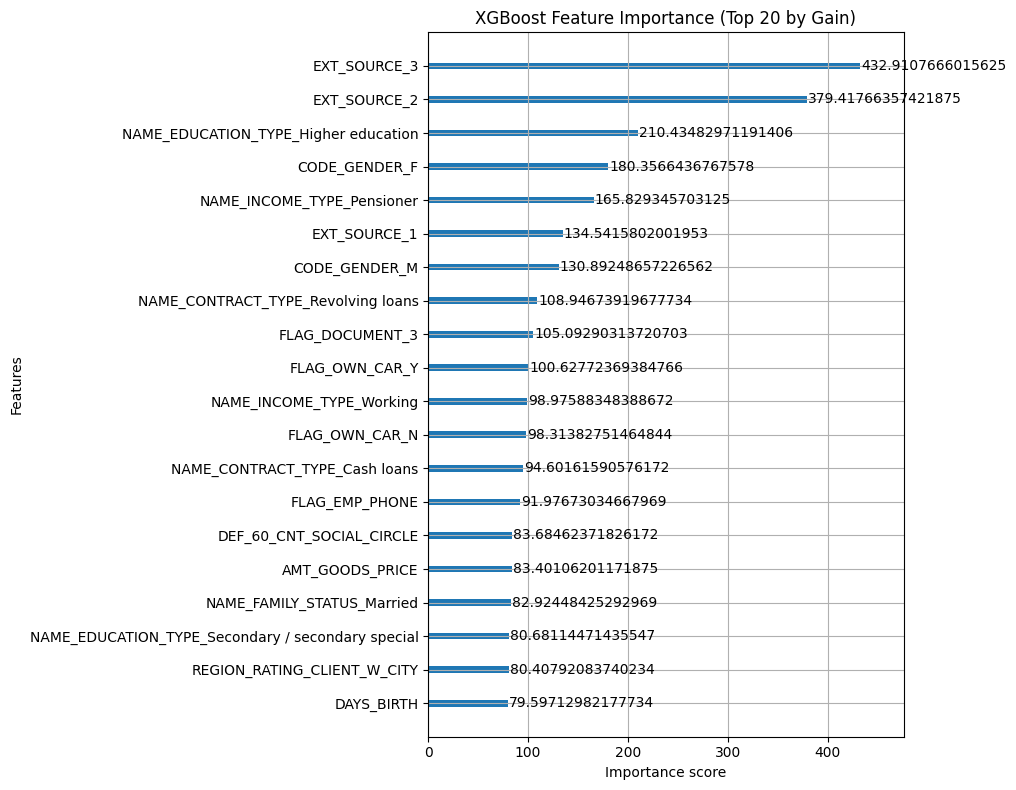

Saved: xgb_feature_importance.png


In [59]:
# 4.5 Feature Importance Plot

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_best, ax=ax, max_num_features=20, importance_type='gain')
ax.set_title('XGBoost Feature Importance (Top 20 by Gain)')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xgb_feature_importance.png")

## Section 5: Multi-Layer Perceptron (MLP)

In [60]:
# 5.1 Baseline MLPClassifier with class imbalance fix
# sklearn MLPClassifier has no scale_pos_weight — use sample_weight instead

from sklearn.utils.class_weight import compute_sample_weight

# Compute per-sample weights so minority class (default) gets 11x more weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print(f"Sample weight for class 0: {sample_weights[y_train==0][0]:.3f}")
print(f"Sample weight for class 1: {sample_weights[y_train==1][0]:.3f}")

mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_SEED,
    verbose=False
)

start = time.time()
mlp_baseline.fit(X_train_scaled, y_train, sample_weight=sample_weights)
mlp_train_time = time.time() - start

val_pred = mlp_baseline.predict(X_val_scaled)
print(f"\nActual epochs run: {mlp_baseline.n_iter_}")
print(f"Training time:     {mlp_train_time:.2f}s")
print(f"Val F1:            {f1_score(y_val, val_pred):.4f}")

Sample weight for class 0: 0.544
Sample weight for class 1: 6.194

Actual epochs run: 12
Training time:     10.60s
Val F1:            0.2464


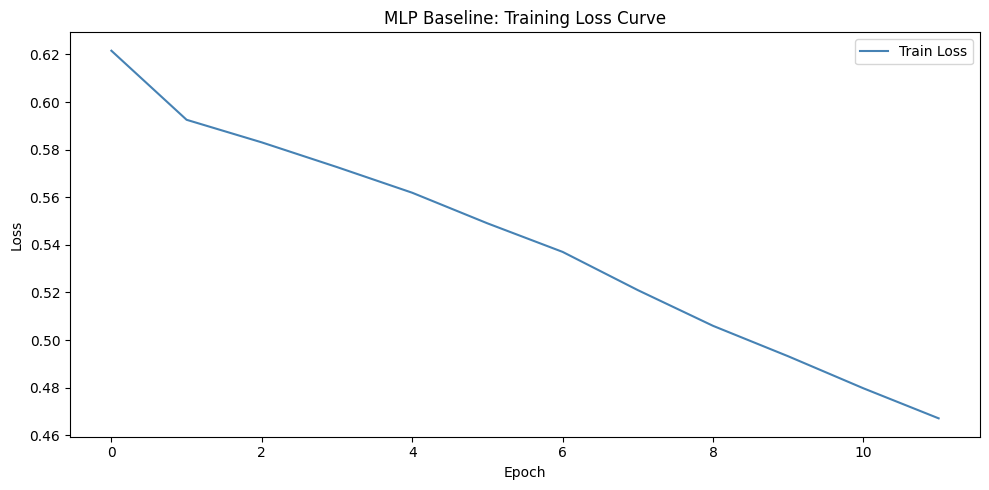

Saved: mlp_baseline_loss.png


In [61]:
# 5.2 Plot training loss curve using loss_curve_ attribute

plt.figure(figsize=(10, 5))
plt.plot(mlp_baseline.loss_curve_, label='Train Loss', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Baseline: Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_baseline_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mlp_baseline_loss.png")

(64,): 200 epochs, Val F1=0.2342
(128, 64): 200 epochs, Val F1=0.2141
(256, 128, 64): 146 epochs, Val F1=0.1855


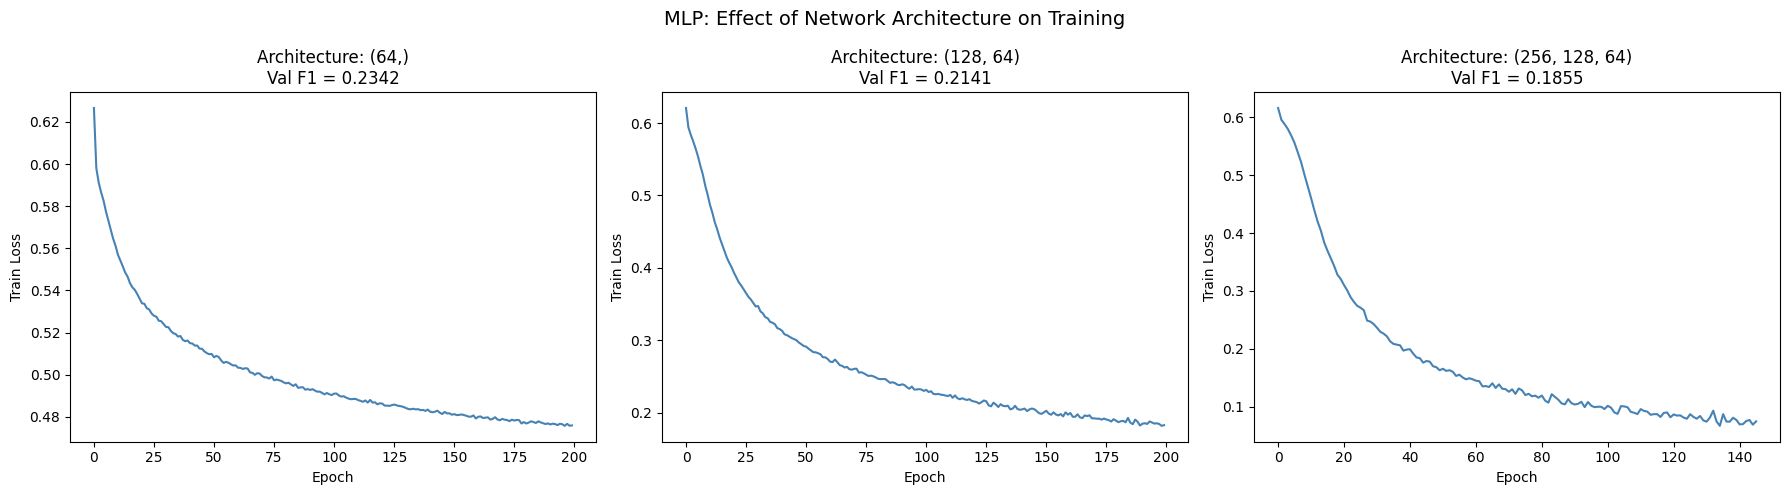

Saved: mlp_architectures.png


In [62]:
# 5.3 Effect of architecture: shallow vs deep vs wide

architectures = {
    '(64,)':          (64,),
    '(128, 64)':      (128, 64),
    '(256, 128, 64)': (256, 128, 64),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
arch_results = {}

for idx, (name, arch) in enumerate(architectures.items()):
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=200,           # allow more epochs than baseline
        early_stopping=False,   # turn off early stopping to see full curve
        random_state=RANDOM_SEED
    )
    model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

    val_pred = model.predict(X_val_scaled)
    val_f1 = f1_score(y_val, val_pred)
    arch_results[name] = val_f1

    axes[idx].plot(model.loss_curve_, color='steelblue')
    axes[idx].set_title(f'Architecture: {name}\nVal F1 = {val_f1:.4f}')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Train Loss')

    print(f"{name}: {model.n_iter_} epochs, Val F1={val_f1:.4f}")

plt.suptitle('MLP: Effect of Network Architecture on Training', fontsize=14)
plt.tight_layout()
plt.savefig('mlp_architectures.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mlp_architectures.png")

In [63]:
# 5.4 Effect of activation function (relu vs tanh) and learning rate

activations = ['relu', 'tanh']
learning_rates = [0.001, 0.01, 0.1]
results_54 = []

for activation in activations:
    for lr in learning_rates:
        model = MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation=activation,
            learning_rate_init=lr,
            max_iter=200,
            early_stopping=False,
            random_state=RANDOM_SEED
        )
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
        val_pred = model.predict(X_val_scaled)
        val_f1 = f1_score(y_val, val_pred)
        results_54.append({
            'activation': activation,
            'learning_rate': lr,
            'val_f1': val_f1,
            'epochs': model.n_iter_
        })
        print(f"activation={activation}, lr={lr}: Val F1={val_f1:.4f}, epochs={model.n_iter_}")

# Summary table
results_54_df = pd.DataFrame(results_54)
pivot = results_54_df.pivot(index='activation', columns='learning_rate', values='val_f1')
print("\n=== Val F1 Summary ===")
print(pivot.round(4))

activation=relu, lr=0.001: Val F1=0.2141, epochs=200
activation=relu, lr=0.01: Val F1=0.2285, epochs=111
activation=relu, lr=0.1: Val F1=0.0000, epochs=28
activation=tanh, lr=0.001: Val F1=0.1777, epochs=200
activation=tanh, lr=0.01: Val F1=0.2438, epochs=30
activation=tanh, lr=0.1: Val F1=0.2115, epochs=12

=== Val F1 Summary ===
learning_rate   0.001   0.010   0.100
activation                           
relu           0.2141  0.2285  0.0000
tanh           0.1777  0.2438  0.2115


In [64]:
# Create scaled version of the tuning subsample (needed for MLP tuning)
X_tune_scaled = scaler.transform(X_tune)
print(f"X_tune_scaled shape: {X_tune_scaled.shape}")

X_tune_scaled shape: (64577, 224)


In [65]:
# 5.5 Hyperparameter Tuning for MLP
# Use subsample of train for speed — same approach as XGBoost tuning

from sklearn.model_selection import RandomizedSearchCV

param_dist_mlp = {
    'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
    'activation':         ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],   # exclude 0.1 — relu+0.1 failed
    'max_iter':           [100, 200],
}

mlp_cv = MLPClassifier(random_state=RANDOM_SEED)

mlp_rscv = RandomizedSearchCV(
    mlp_cv,
    param_distributions=param_dist_mlp,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

# Use same 30% subsample as XGBoost for consistency
mlp_rscv.fit(X_tune_scaled, y_tune,
             sample_weight=compute_sample_weight('balanced', y=y_tune))

print(f"\nBest params: {mlp_rscv.best_params_}")
print(f"Best CV F1:  {mlp_rscv.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best params: {'max_iter': 100, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (64,), 'activation': 'relu'}
Best CV F1:  0.4257


In [66]:
# 5.5b Train final MLP on full training set with best params

mlp_best = MLPClassifier(
    **mlp_rscv.best_params_,
    random_state=RANDOM_SEED
)

start = time.time()
mlp_best.fit(X_train_scaled, y_train,
             sample_weight=compute_sample_weight('balanced', y=y_train))
mlp_train_time = time.time() - start

val_pred_mlp = mlp_best.predict(X_val_scaled)
print(f"Epochs run:    {mlp_best.n_iter_}")
print(f"Training time: {mlp_train_time:.2f}s")
print(f"Val F1:        {f1_score(y_val, val_pred_mlp):.4f}")

Epochs run:    100
Training time: 51.85s
Val F1:        0.2311


## Section 6: GBDT vs MLP Comparison

In [67]:
# 6.1 Evaluate both models on test set

def evaluate_model(model, X, y, model_name):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Model':     model_name,
        'Accuracy':  accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall':    recall_score(y, y_pred),
        'F1-Score':  f1_score(y, y_pred),
        'AUC-PR':    average_precision_score(y, y_proba),
        'ROC-AUC':   roc_auc_score(y, y_proba),
    }

xgb_metrics = evaluate_model(xgb_best,  X_test,        y_test, 'XGBoost (GBDT)')
mlp_metrics = evaluate_model(mlp_best,  X_test_scaled, y_test, 'MLP')

comparison_df = pd.DataFrame([xgb_metrics, mlp_metrics]).set_index('Model')
print("=== Test Set Comparison ===")
print(comparison_df.round(4))

=== Test Set Comparison ===
                Accuracy  Precision  Recall  F1-Score  AUC-PR  ROC-AUC
Model                                                                 
XGBoost (GBDT)    0.7141     0.1712  0.6617    0.2720  0.2402   0.7557
MLP               0.7216     0.1528  0.5389    0.2381  0.1648   0.6895


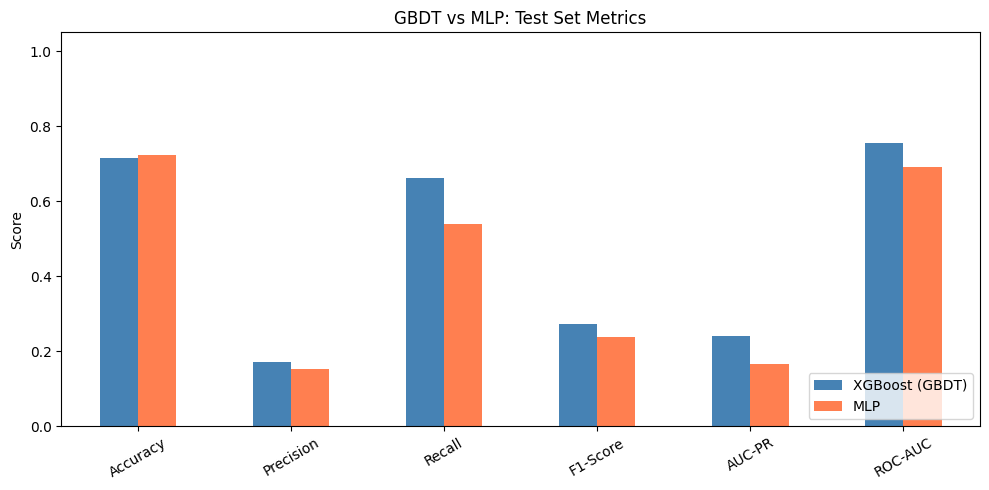

Saved: comparison_metrics.png


In [68]:
# 6.2 Summary comparison bar chart

comparison_df.T.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral'])
plt.title('GBDT vs MLP: Test Set Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_metrics.png")

XGBoost training time: 10.58s
MLP training time:     51.85s


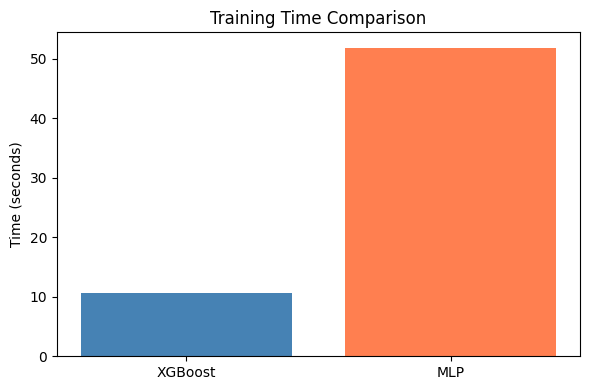

Saved: comparison_training_time.png


In [69]:
# 6.3 Training time comparison

print(f"XGBoost training time: {xgb_train_time:.2f}s")
print(f"MLP training time:     {mlp_train_time:.2f}s")

plt.figure(figsize=(6, 4))
plt.bar(['XGBoost', 'MLP'], [xgb_train_time, mlp_train_time],
        color=['steelblue', 'coral'])
plt.ylabel('Time (seconds)')
plt.title('Training Time Comparison')
plt.tight_layout()
plt.savefig('comparison_training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_training_time.png")

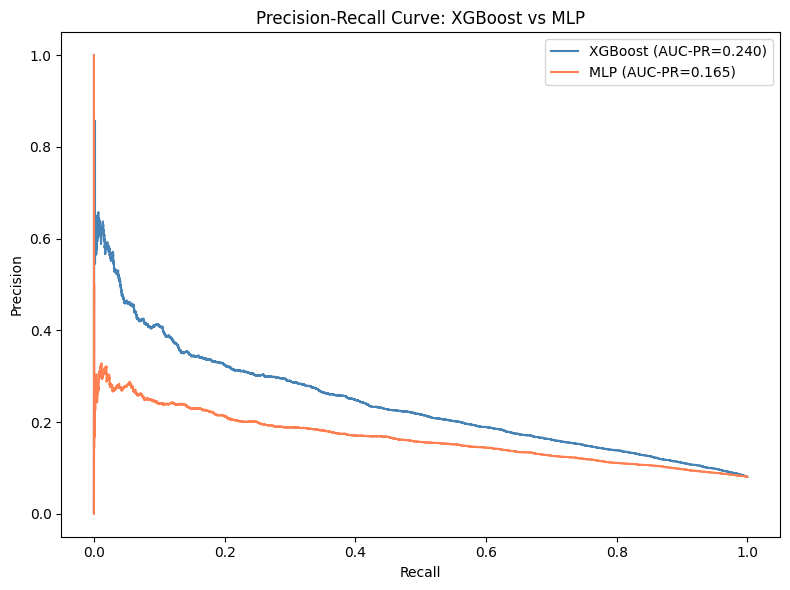

Saved: comparison_pr_curve.png


In [70]:
# 6.4 Precision-Recall Curve for both models

xgb_proba = xgb_best.predict_proba(X_test)[:, 1]
mlp_proba = mlp_best.predict_proba(X_test_scaled)[:, 1]

xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_proba)
mlp_prec, mlp_rec, _ = precision_recall_curve(y_test, mlp_proba)

xgb_aucpr = average_precision_score(y_test, xgb_proba)
mlp_aucpr = average_precision_score(y_test, mlp_proba)

plt.figure(figsize=(8, 6))
plt.plot(xgb_rec, xgb_prec, label=f'XGBoost (AUC-PR={xgb_aucpr:.3f})', color='steelblue')
plt.plot(mlp_rec, mlp_prec, label=f'MLP (AUC-PR={mlp_aucpr:.3f})', color='coral')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: XGBoost vs MLP')
plt.legend()
plt.tight_layout()
plt.savefig('comparison_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_pr_curve.png")

## Section 7: AI Tool Disclosure

### AI Tools Used

**Claude Code (Anthropic)**
- Scaffolded the notebook structure and section skeleton
- Debugged errors (XGBoost API changes, class imbalance, cell ordering)
- Explained concepts on request (MLP architecture, cross-validation, data leakage)
- Generated code for cells after discussion and explanation of each step

### Personal Contributions
- Selected the Home Credit Default Risk dataset
- Ran all cells and interpreted outputs
- Identified and understood the class imbalance problem from EDA results
- Made decisions on preprocessing thresholds (e.g., 60% missing value cutoff)
- Analyzed and interpreted all plots and metric results
- Wrote report analysis sections based on actual output values
- Understood every line of code before it was executed — no blind copy-paste